### Setup

In [1]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time as t
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import pickle
import json

In [2]:
# cities = ["Columbus", "Philadelphia", "Chicago", "City of New York"]  # Change this as necessary
cities = ["Columbus", "Philadelphia", "Chicago", "City of New York"]

drive.mount('/content/gdrive/', force_remount=True)
personal_dir = "./gdrive/MyDrive/DeliverAI Data Folder/"

Mounted at /content/gdrive/


### Min Perc Graphs

Files in directory :  ['Results', 'Original Location Data', 'Processed Location Data', 'Census Data', 'Hotspot Data', 'Q_boltzman.npy', 'Super Spots', 'distance_matrix.npy', 'time_matrix.npy', 'Q_epsilon.npy', 'Images', 'Q Tables', 'avg_hotspot_data.json', 'Deliveries']
./gdrive/MyDrive/DeliverAI Data Folder/Columbus - RL Delivery Data/Images Already Exists


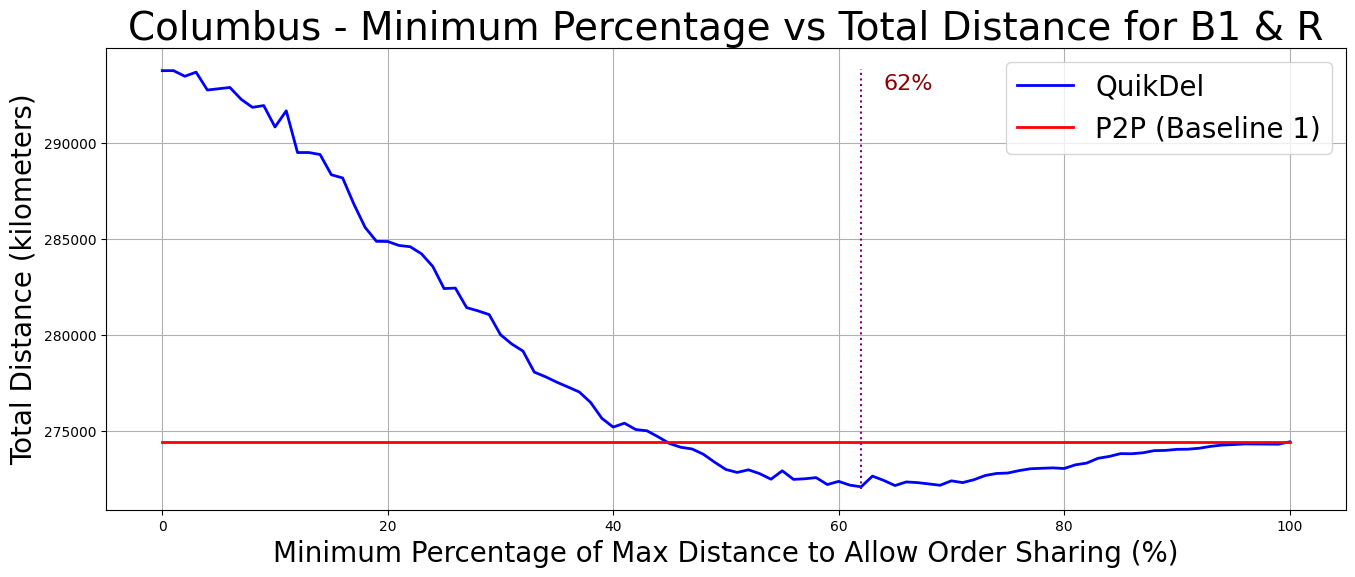

Files in directory :  ['Original Location Data', 'Processed Location Data', 'Census Data', 'Hotspot Data', 'Results', 'Images', 'Q Tables', 'avg_hotspot_data.json', 'Deliveries']
./gdrive/MyDrive/DeliverAI Data Folder/Chicago - RL Delivery Data/Images Already Exists


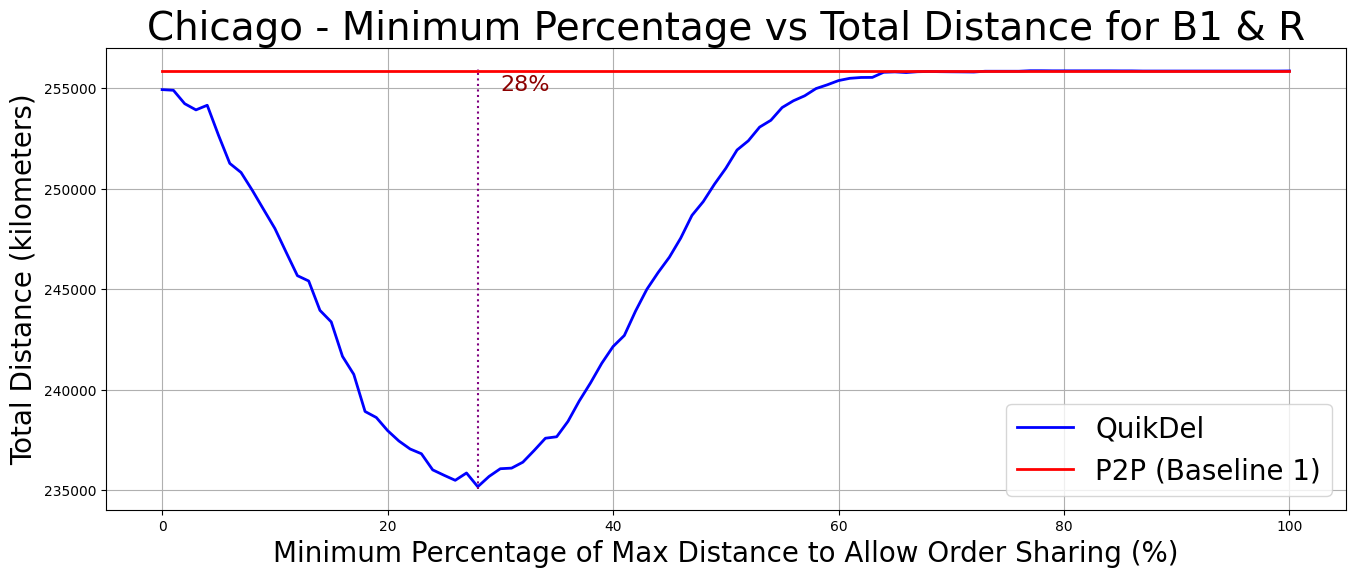

In [ ]:
for city_name in cities:
  data_dir = f"{personal_dir}{city_name} - RL Delivery Data"

  # See directory content
  data = os.listdir(data_dir)
  print("Files in directory : ", data)

  deliveries_dir = data_dir + f"/Deliveries"
  deliveries_graphing_dir = deliveries_dir + "/Graphing"

  percs_to_check = list(range(101))

  with open (deliveries_graphing_dir + f"/sim_results", 'rb') as fp:
    res_dist = pickle.load(fp)

  with open (deliveries_graphing_dir + f"/baseline_results", 'rb') as fp:
    base1_dist = pickle.load(fp)

  time = np.linspace(0, 100, len(percs_to_check))

  plt.figure(figsize=(16,6))
  plt.plot(percs_to_check, res_dist, label='QuikDel', color='b', linewidth=2)
  plt.plot(percs_to_check, base1_dist, label='P2P (Baseline 1)', color='r', linewidth=2)

  min_perc = percs_to_check[np.argmin(res_dist)]
  plt.vlines(x = min_perc, ymin = min(res_dist)-100, ymax = max(res_dist)+100, colors = 'purple', linestyle = ':')
  plt.text(x=min_perc+2, y=max(res_dist)-1000, s=f'{min_perc}%', fontsize = 16, color='darkred')


  plt.xlabel('Minimum Percentage of Max Distance to Allow Order Sharing (%)', fontsize = 20)
  plt.ylabel('Total Distance (kilometers)', fontsize = 20)
  plt.title(f'{city_name.replace("City of ", "")} - Minimum Percentage vs Total Distance for P2P & QD', fontsize = 28)
  plt.legend(fontsize=20, loc='best', frameon=True)
  plt.grid(True)

  try:
    os.mkdir(data_dir + "/Images")
  except:
    print(data_dir + "/Images" + " Already Exists")

  plt.show()

### Reward Graphs

In [34]:
ratios = [10, 15]

In [35]:
# Mapping for city-specific percentage IDs
city_ratio_perc = {
  "Columbus": {5: 54, 10: 61, 15: 62},
  "Philadelphia": {5: 37, 10: 34, 15: 30},
  "Chicago": {5: 29, 10: 28, 15: 31},
  "City of New York": {5: 29, 10: 29, 15: 29}
}

# Initialize storage
all_data = []

def load_and_average_rewards(file_path, chunk_size=6):
  """Load reward data from JSON and average in chunks."""
  with open(file_path) as f:
    res = json.load(f)
  rewards = [item[0] for item in res["reward_by_time"].values()]
  averaged_rewards = [np.mean(rewards[i:i+chunk_size]) for i in range(0, len(rewards), chunk_size)]
  return averaged_rewards

# Main loop
for city_ratio in ratios:
  for city_name in cities:
    reward_runs = []

    for i in range(10):
      data_dir = f"{personal_dir}{city_name} - RL Delivery Data"
      file_name = f'results_0-0300-001-010-[0.25, 0.75]-0{city_ratio_perc[city_name][city_ratio]}-11_{city_ratio-3}_{city_ratio}_{i}.json'
      file_path = os.path.join(data_dir, f"Results/Data-{city_ratio-3}-{city_ratio}/Repeating", file_name)

      try:
        averaged_rewards = load_and_average_rewards(file_path)
        reward_runs.append(averaged_rewards)
      except FileNotFoundError:
        print(f"Warning: File not found {file_path}")
        continue

    # Pad to match lengths
    if reward_runs:
      max_len = max(len(run) for run in reward_runs)
      reward_runs_padded = [run + [0] * (max_len - len(run)) for run in reward_runs]

      # Compute mean and std
      mean_rewards = np.mean(reward_runs_padded, axis=0)
      std_rewards = np.std(reward_runs_padded, axis=0)

      # Save results
      for minute, (mean_val, std_val) in enumerate(zip(mean_rewards, std_rewards)):
        all_data.append({
          "City": city_name,
          "Ratio": city_ratio,
          "Minute": minute,
          "MeanReward": mean_val,
          "StdReward": std_val
        })

results_df = pd.DataFrame(all_data)

results_df = results_df.sort_values(["City", "Ratio", "Minute"]).reset_index(drop=True)
results_df.head()

,City,Ratio,Minute,MeanReward,StdReward
0,Chicago,10,0,0.635729,0.140164
1,Chicago,10,1,0.888744,0.151697
2,Chicago,10,2,1.219214,0.156661
3,Chicago,10,3,1.502355,0.187401
4,Chicago,10,4,2.102735,0.348936


In [36]:
# Settings
hours = 1
peaks = [0.25, 0.75]
highlight_regions = [(peak * hours * 60 - 5, peak * hours * 60 + 5) for peak in peaks]

linestyles = {
    5: 'solid',
    10: 'dashed',
    15: 'dotted'
}

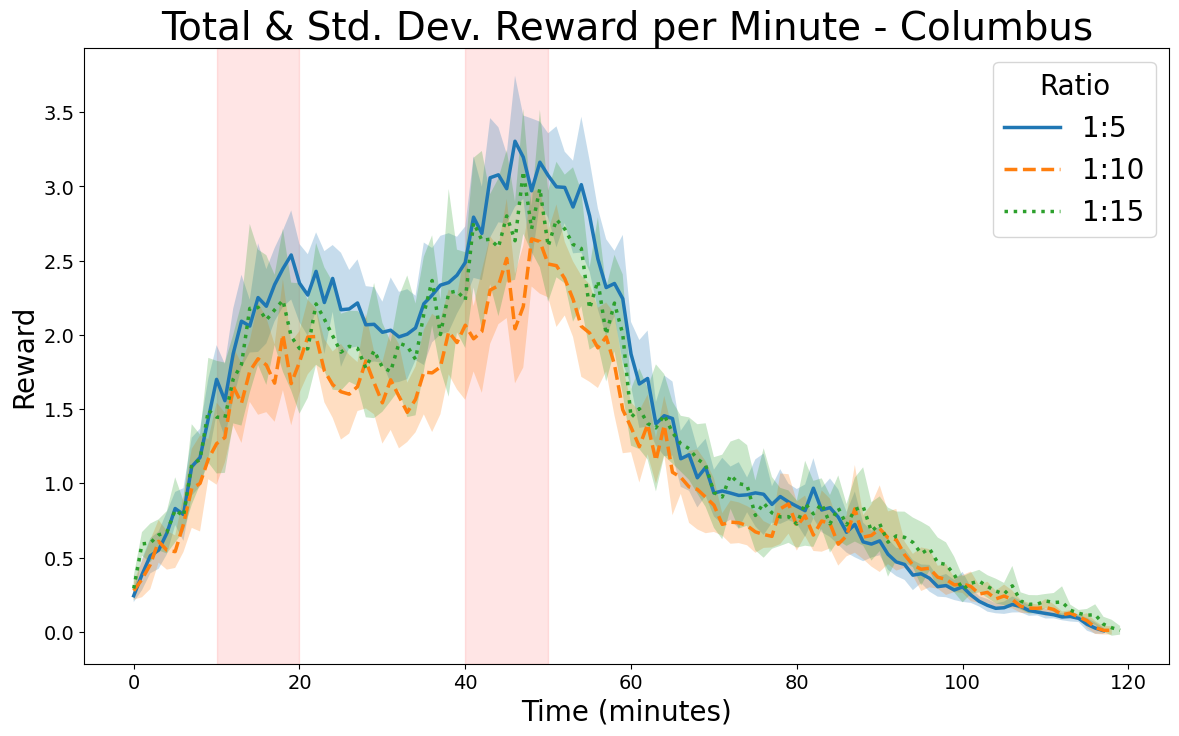

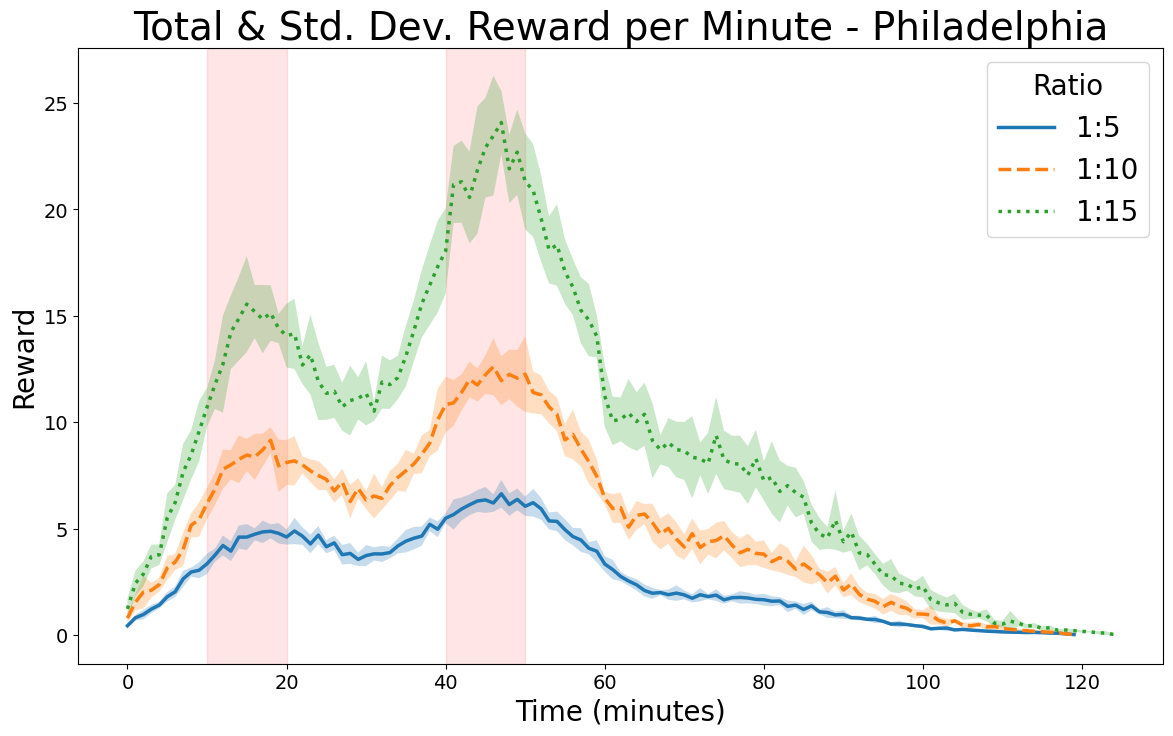

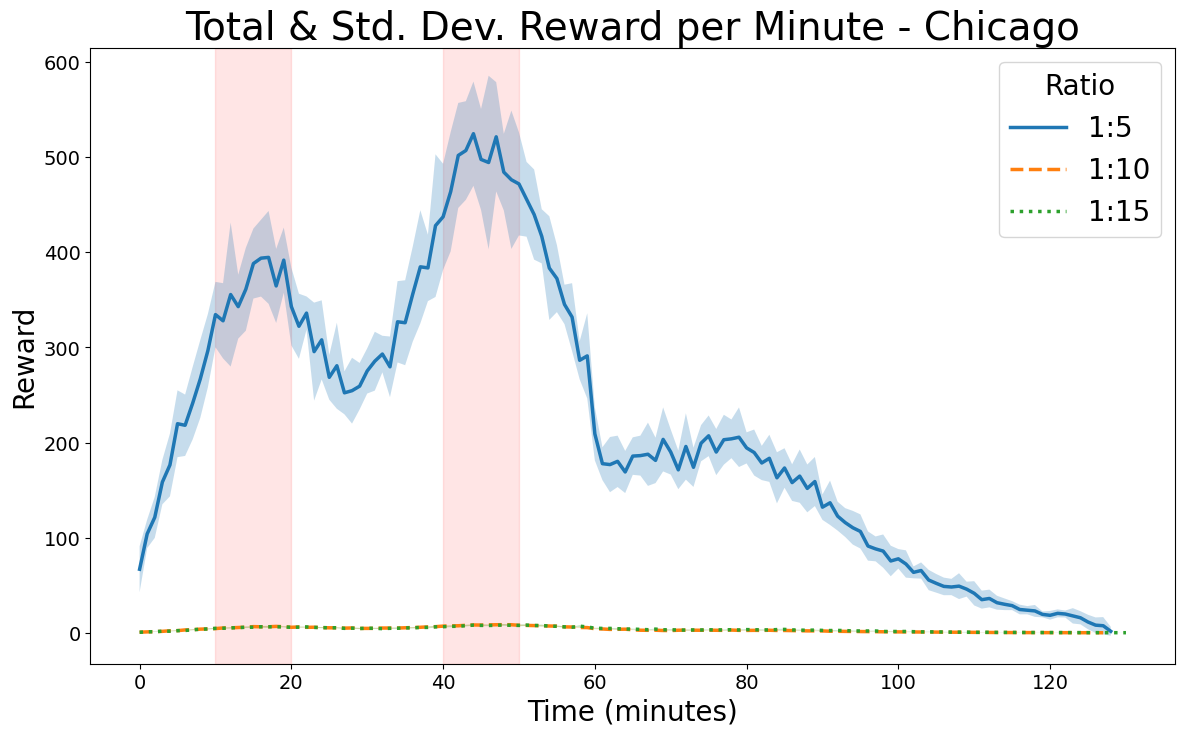

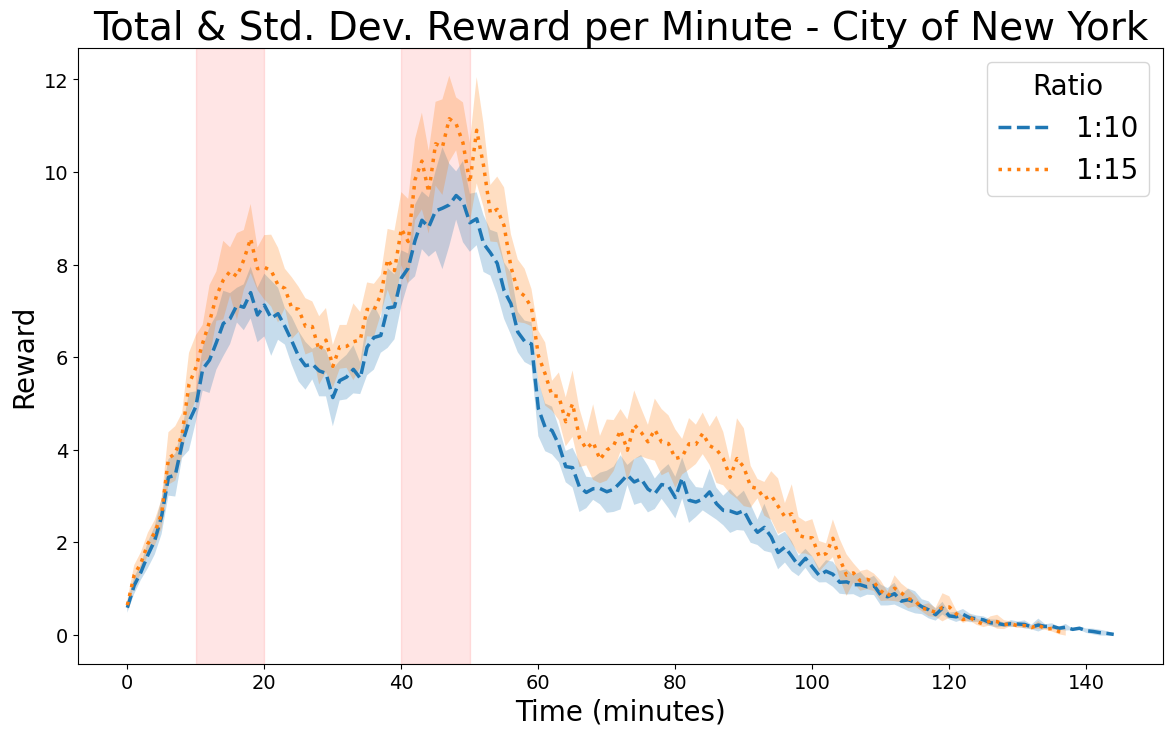

In [33]:
for city in cities:
  plt.figure(figsize=(14, 8))

  for start, end in highlight_regions:
    plt.axvspan(start, end, color='red', alpha=0.1)

  for ratio in ratios:
    # Filter data
    subset = results_df[(results_df["City"] == city) & (results_df["Ratio"] == ratio)].sort_values("Minute")
    if subset.empty:
      continue  # Skip missing data

    x = subset["Minute"].values
    mean = subset["MeanReward"].values
    std = subset["StdReward"].values

    plt.plot(x, mean,
            label=f"1:{ratio}",
            linestyle=linestyles[ratio],
            linewidth=2.5)
    plt.fill_between(x, mean - std, mean + std,
                    alpha=0.25)

  # Plot settings
  plt.xlabel("Time (minutes)", fontsize=20)
  plt.ylabel("Reward", fontsize=20)
  plt.title(f"Total & Std. Dev. Reward per Minute - {city}", fontsize=28)
  plt.xticks(fontsize=14)
  plt.yticks(fontsize=14)
  plt.legend(title="Ratio", fontsize=20, title_fontsize=20)

  plt.show()

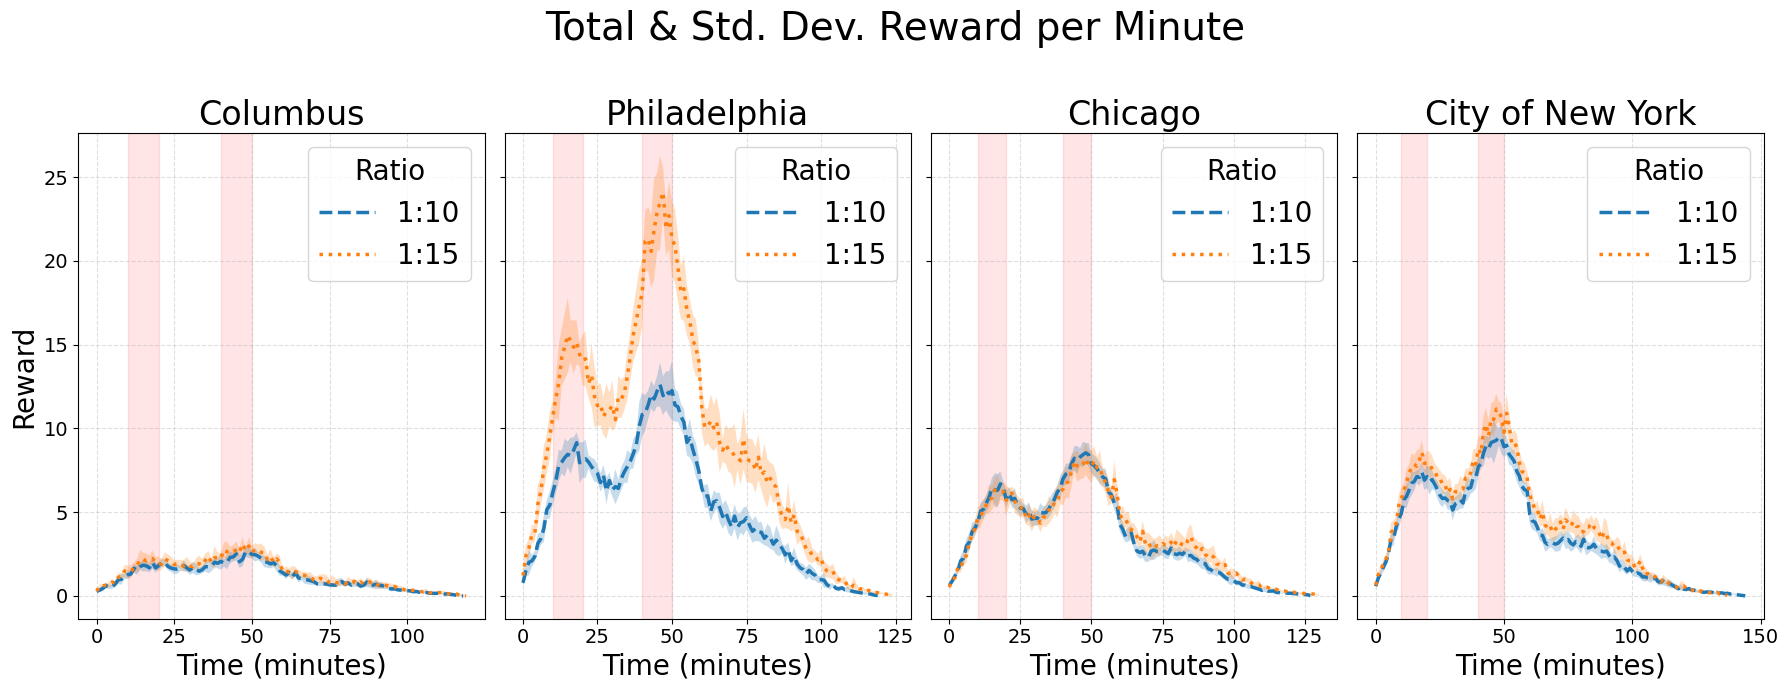

In [37]:
# Set up subplots
fig, axes = plt.subplots(1, len(cities), figsize=(18, 7), sharey=True)

# Global limits
x_min = results_df["Minute"].min()
x_max = results_df["Minute"].max()
y_min = 0
y_max = (results_df["MeanReward"] + results_df["StdReward"]).max() * 1.05

# Plot each city
for ax, city in zip(axes, cities):
    # Plot both peak regions regardless of subplot x-range
    for start, end in highlight_regions:
        ax.axvspan(start, end, color='red', alpha=0.1)

    for ratio in ratios:
        subset = results_df[(results_df["City"] == city) & (results_df["Ratio"] == ratio)].sort_values("Minute")
        if subset.empty:
            continue

        x = subset["Minute"].values
        mean = subset["MeanReward"].values
        std = subset["StdReward"].values

        ax.plot(x, mean, label=f"1:{ratio}", linestyle=linestyles[ratio], linewidth=2.5)
        ax.fill_between(x, mean - std, mean + std, alpha=0.25)

    ax.set_title(f"{city}", fontsize=24)
    ax.set_xlabel("Time (minutes)", fontsize=20)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(title="Ratio", fontsize=20, title_fontsize=20)
    ax.tick_params(axis='both', labelsize=14)




# Shared y-label and global title
axes[0].set_ylabel("Reward", fontsize=20)
fig.suptitle("Total & Std. Dev. Reward per Minute", fontsize=28)
plt.tight_layout(rect=[0, 0, 1, 0.95])



plt.show()


In [53]:
data_dir = f"{personal_dir}Chicago - RL Delivery Data"
ratio_test = [5, 29]
i_num = 0
file_name = f'results_0-0300-001-010-[0.25, 0.75]-0{ratio_test[1]}-11_{ratio_test[0]-3}_{ratio_test[0]}_{i_num}.json'
file_path = os.path.join(data_dir, f"Results/Data-{ratio_test[0]-3}-{ratio_test[0]}/Repeating", file_name)

with open(file_path) as f:
  TEMP_CHICAGO = json.load(f)
TEMP_CHICAGO.keys()

dict_keys(['shares', 'success_rate', 'success_rate_grouped', 'description', 'sharing', 'distances', 'distances_tagged', 'times', 'times_tagged', 'wait', 'hops', 'hops_all', 'CDV', 'PDV', 'destination_success', 'source_success', 'order_rate', 'non_local_order_rate', 'reward_by_time', 'reward_by_step'])

In [54]:
TEMP_CHICAGO['success_rate']

0.9608394634357421